In [1]:
import optrisROI
import temperatureimage as ti
import camera

cp = camera.AUGUST_CAMERA_POSITION

In [2]:
import numpy as np
import optrisROI
import temperatureimage as ti
import camera


cp = camera.AUGUST_CAMERA_POSITION

datasets = []
positions_10V = ["LLL", "MLL", "RLL", "LML", "MML", "RML", "LMR", "MMR", "RMR", "LRR", "MRR", "RRR", "LR", "RL",
                 "TTT", "MTT", "BTT", "TMT", "MMT", "BMT", "TMB", "MMB", "BMB", "TBB", "MBB", "BBB"]


# Iterate through each position and add to datsaets
position_counter = 0
for position in positions_10V:
    for i in range(3): 
        path = "C:/Users/ssuub/Desktop/EDET80k_Damage/Lasing Analysis/apps/Simulation and BeamLib/Caleb/New PC Data/10V_825mA_" + position + str(i+1) + ".csv"
        data = ti.TemperatureSet(path, position)
        data.perspectiveCorrect()
        datasets.append(data)
    position_counter += 1

In [3]:
rois = []
roi_prms = [[[182, 119], [195, 119], [188, 280], [182, 280]],
            [[182, 119], [220, 119], [205, 280], [182, 280]],
            [[182, 119], [248, 119], [233, 280], [182, 280]],
            [[185, 119], [265, 119], [250, 280], [182, 280]],
            [[205, 119], [285, 119], [270, 280], [195, 280]],
            [[220, 119], [300, 119], [290, 280], [210, 280]],
            [[233, 119], [313, 119], [303, 280], [228, 280]],
            [[245, 119], [328, 119], [318, 280], [245, 280]],
            [[265, 119], [343, 119], [338, 280], [260, 280]],
            [[282, 119], [343, 119], [343, 280], [280, 280]],
            [[310, 119], [343, 119], [343, 280], [305, 280]],
            [[335, 119], [343, 119], [343, 280], [333, 280]],
            [[270, 119], [343, 119], [343, 150], [260, 280], [182, 280], [182, 260]],
            [[182, 119], [265, 119], [343, 250], [343, 280], [275, 280], [182, 135]],
            [[182, 119], [343, 119], [343, 143], [182, 133]],
            [[182, 119], [343, 119], [343, 160], [182, 155]],
            [[182, 119], [343, 119], [343, 183], [182, 180]],
            [[182, 119], [343, 125], [343, 200], [182, 195]],
            [[182, 130], [343, 142], [343, 220], [182, 210]],
            [[182, 150], [343, 162], [343, 240], [182, 230]],
            [[182, 170], [343, 185], [343, 260], [182, 250]],
            [[182, 185], [343, 205], [343, 280], [182, 265]],
            [[182, 205], [343, 220], [343, 280], [182, 280]],
            [[182, 215], [343, 240], [343, 280], [182, 280]],
            [[182, 242], [343, 258], [343, 280], [182, 280]],
            [[182, 270], [230, 280], [182, 280]]
            ]

for prm in roi_prms:
    roi = optrisROI.PolyROI(prm)
    for i in range(3):
        rois.append(roi)

In [4]:
composite = ti.TemperatureComposite(datasets, rois, "Composite Data 10V")

Loading Data ---------------------------------------- 100% 0:00:00
Compositing Data ---------------------------------------- 100% 0:00:0000:0100:02


In [18]:
composite.render3D(roi = optrisROI.CHIP)

In [14]:
fit, func = composite.polyfit(degree = 15, roi = optrisROI.CHIP)

RMS residual = 0.15552581774142157


c:\Users\ssuub\Desktop\EDET80k_Damage\Lasing Analysis\apps\thermal image analysis\temperatureimage.py:200: OptimizeWarning:

Covariance of the parameters could not be estimated



In [9]:
fit.render3D()

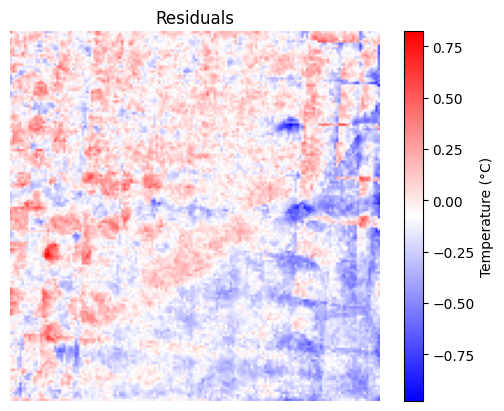

In [21]:
residuals = ti.TemperatureSet(composite.data[120:280,184:344] - fit.data, "Residuals")
residuals.render(cmap='bwr')